<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Module 0 · Foundations</h4>
<h1 align="center">Seaborn Essentials</h1>
<p align="center"><i>Fast, good-looking statistical plots built on top of Matplotlib</i></p>

---

## About This Notebook

This is the Seaborn section of the Module 0 refresher, split out so it can be run on its own,
in any order relative to the other Module 0 notebooks. See `00_numpy_and_pandas.ipynb` for
the NumPy/pandas fundamentals, and `01_matplotlib.ipynb` / `03_plotly.ipynb` for the other two
visualization libraries.

## 0. Recreating the Dataset from Notebook 0

This notebook is meant to run on its own, in any order relative to the other Module 0
notebooks. So before we get to plotting, we rebuild the exact same synthetic "store sales"
DataFrame introduced in `00_numpy_and_pandas.ipynb`, using the same random seed (`42`), so the
data -- and every chart built from it -- is identical no matter which notebook you open
first.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 300

regions = rng.choice(["North", "South", "East", "West"], size=n, p=[0.3, 0.3, 0.2, 0.2])
categories = rng.choice(["Electronics", "Grocery", "Apparel"], size=n)
units_sold = rng.poisson(lam=20, size=n)
unit_price = np.round(rng.uniform(5, 200, size=n), 2)
customer_rating = np.clip(rng.normal(loc=4.0, scale=0.7, size=n), 1, 5).round(1)

sales = pd.DataFrame({
    "region": regions,
    "category": categories,
    "units_sold": units_sold,
    "unit_price": unit_price,
    "revenue": np.round(units_sold * unit_price, 2),
    "customer_rating": customer_rating,
})

# Inject a few realistic missing values, so plots involving customer_rating have gaps to handle
missing_idx = rng.choice(sales.index, size=15, replace=False)
sales.loc[missing_idx, "customer_rating"] = np.nan

print(sales.shape)
sales.head()

(300, 6)


,region,category,units_sold,unit_price,revenue,customer_rating
0,East,Grocery,23,74.69,1717.87,3.9
1,South,Apparel,13,56.64,736.32,4.3
2,West,Apparel,24,124.04,2976.96,2.5
3,East,Electronics,21,45.05,946.05,4.0
4,North,Apparel,29,178.23,5168.67,5.0


### 0.1 Shared plotting imports and palette

Seaborn is built on top of Matplotlib, so we bring in both, plus the same color palette used
throughout Module 0.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BLUE, RED, GREEN, ORANGE, PURPLE = "#4C72B0", "#C44E52", "#55A868", "#DD8452", "#8172B2"

## 1. Seaborn Essentials

Seaborn wraps Matplotlib with **statistical defaults**: sensible color palettes, automatic
legends, and one-line access to plots (violin plots, heatmaps, pairplots) that would take
many lines of raw Matplotlib to reproduce. Reach for Seaborn whenever you want a good-looking
statistical plot fast; drop back to raw Matplotlib when you need fine-grained control over
every visual element.

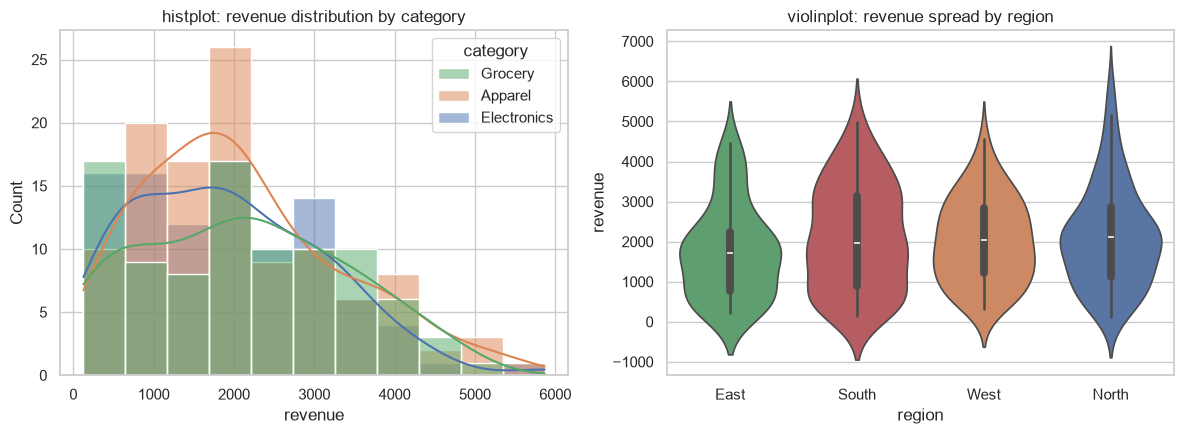

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(sales, x="revenue", hue="category", kde=True, ax=axes[0],
             palette={"Electronics": BLUE, "Grocery": GREEN, "Apparel": ORANGE})
axes[0].set_title("histplot: revenue distribution by category")

sns.violinplot(sales, x="region", y="revenue", hue="region", ax=axes[1],
               palette={"North": BLUE, "South": RED, "East": GREEN, "West": ORANGE}, legend=False)
axes[1].set_title("violinplot: revenue spread by region")

plt.tight_layout()
plt.show()

*Use `histplot` when you want a distribution's shape at a glance with an optional smoothed
density curve; use `violinplot` (or `boxplot` for a simpler summary) when comparing that
shape across categories.*

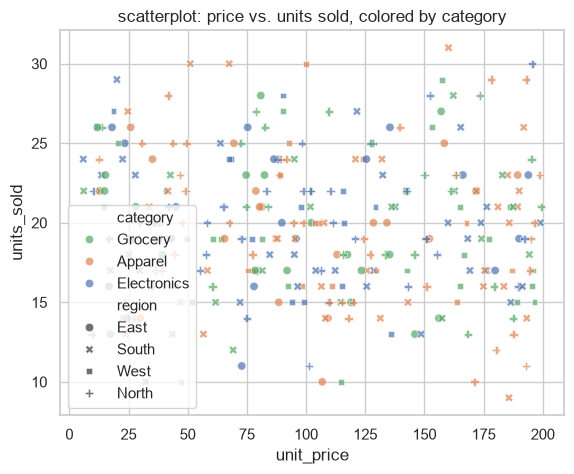

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(sales, x="unit_price", y="units_sold", hue="category", style="region",
                 palette={"Electronics": BLUE, "Grocery": GREEN, "Apparel": ORANGE}, ax=ax, alpha=0.7)
ax.set_title("scatterplot: price vs. units sold, colored by category")
plt.show()

*A raw Matplotlib scatter needs a manual loop to color and label each category. Seaborn's
`hue=`/`style=` parameters do it in one call -- reach for this the moment a scatter needs to
show a third or fourth variable.*

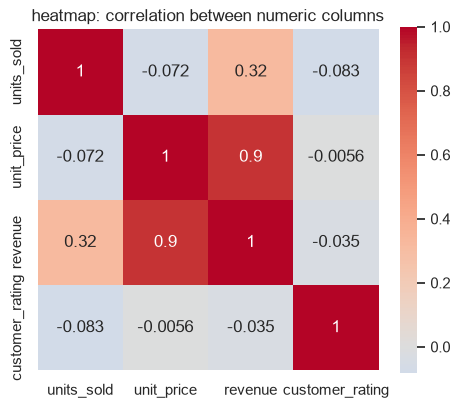

In [5]:
numeric_cols = ["units_sold", "unit_price", "revenue", "customer_rating"]
corr = sales[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("heatmap: correlation between numeric columns")
plt.show()

*`heatmap` is the fastest way to eyeball every pairwise correlation at once -- exactly what
the topic notebooks' EDA sections use before modeling.*

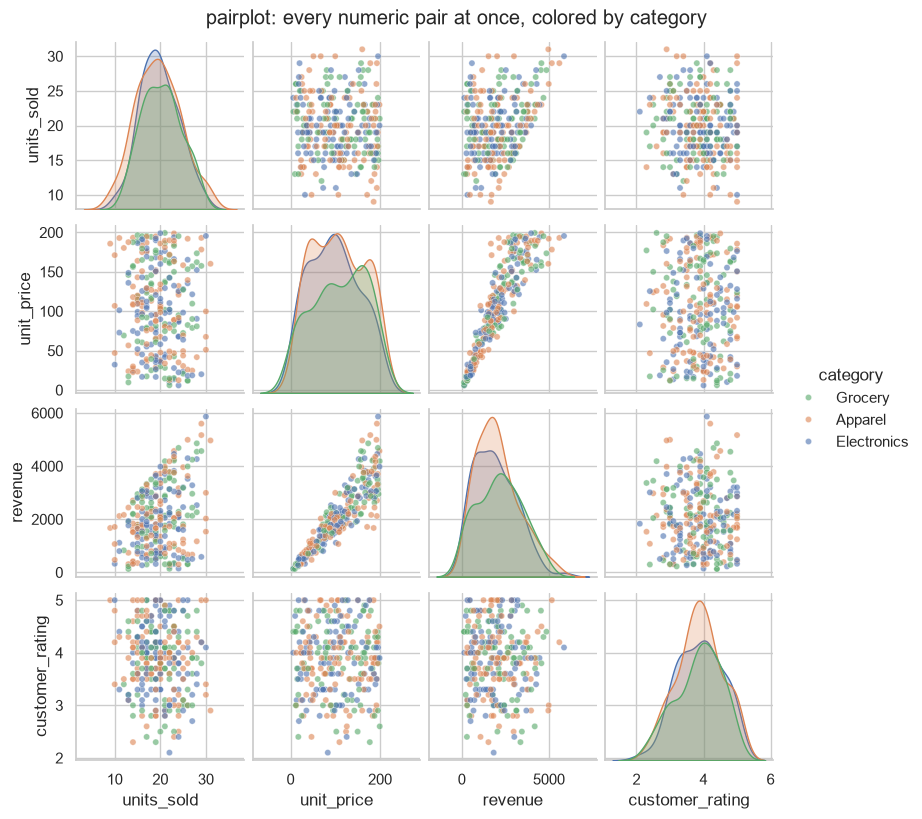

In [6]:
g = sns.pairplot(sales[numeric_cols + ["category"]].dropna(), hue="category",
                  palette={"Electronics": BLUE, "Grocery": GREEN, "Apparel": ORANGE},
                  diag_kind="kde", plot_kws={"alpha": 0.6, "s": 20}, height=2.0)
g.fig.suptitle("pairplot: every numeric pair at once, colored by category", y=1.02)
plt.show()

*`pairplot` is the one-line way to see every pairwise numeric relationship (plus each
variable's own distribution on the diagonal) in a single figure -- a fast first look before
deciding which relationships are worth a closer, dedicated plot.*

## 2. Which Tool, When?

The original Module 0 decision guide is split across this folder's four notebooks, one entry
per notebook. Here is the entry for Seaborn:

- **Seaborn** -- the fastest path to a good-looking *statistical* plot (distributions,
  categorical comparisons, correlation heatmaps, pairwise views) with sensible defaults, at
  the cost of a little less low-level control than raw Matplotlib.

See `00_numpy_and_pandas.ipynb`, `01_matplotlib.ipynb`, and `03_plotly.ipynb` for the other
entries.

## Summary

- Rebuilt the same synthetic "store sales" dataset used across every Module 0 notebook.
- **Seaborn**: `histplot`, `violinplot`, `scatterplot` with `hue`/`style`, `heatmap`, and
  `pairplot`, each tied to when it beats raw Matplotlib.
- When Seaborn is the right call vs. reaching for raw Matplotlib or Plotly instead.

See `00_numpy_and_pandas.ipynb`, `01_matplotlib.ipynb`, and `03_plotly.ipynb` for the rest of
the Module 0 refresher.